# Cross-Modality Comparison 

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import plotly.graph_objects as go
import plotly.express as px

## Load all 6 conditions from the unified-QC cache

In [2]:
IN_DIR = "/mnt/md0/jack-gaa/gaa/analysis/shared_6way_qc_unified/"
ALL_CONDITIONS = ['SR_Std', 'SR_Aug', 'SR_Dis', 'LR_Std', 'LR_Aug', 'LR_Dis']

adatas_raw = {}
for name in ALL_CONDITIONS:
    adatas_raw[name] = sc.read_h5ad(os.path.join(IN_DIR, f"{name}.h5ad"))
    print(f"Loaded {name}: {adatas_raw[name].n_obs:,} cells x {adatas_raw[name].n_vars:,} features")

for name in ALL_CONDITIONS[1:]:
    assert all(adatas_raw[ALL_CONDITIONS[0]].obs_names == adatas_raw[name].obs_names)
print(f"\nConfirmed identical, QC-passed barcodes across all 6: {adatas_raw['SR_Std'].n_obs:,} cells")

Loaded SR_Std: 2,280 cells x 38,606 features
Loaded SR_Aug: 2,280 cells x 121,190 features
Loaded SR_Dis: 2,280 cells x 117,490 features
Loaded LR_Std: 2,280 cells x 27,389 features
Loaded LR_Aug: 2,280 cells x 81,614 features
Loaded LR_Dis: 2,280 cells x 159,670 features

Confirmed identical, QC-passed barcodes across all 6: 2,280 cells


## Discovery gene-level collapse

In [3]:
COLLAPSE_CLASSES = {
    'known_exon', 'extended_exon', 'proximal_novel_exon',
    'known_transcript_intronic', 'known_gene_intronic',
}
KEEP_SEPARATE_CLASSES = {'antisense_exonic', 'antisense_intronic', 'intergenic'}


def parse_discovery_id(var_name):
    parts = var_name.split('|')
    if len(parts) < 3:
        return None, None, None
    context, classification, peak_id = parts[0], parts[1], '|'.join(parts[2:])
    return context, classification, peak_id


def build_gene_map(adata_dis):
    gene_map = {}
    for v in adata_dis.var_names:
        context, cls, peak_id = parse_discovery_id(v)
        if cls in COLLAPSE_CLASSES and context:
            gene_map[v] = context
    return gene_map


def collapse_discovery_to_gene_level(adata_dis, gene_map):
    var_names = list(adata_dis.var_names)
    targets = [gene_map.get(v, v) for v in var_names]
    target_genes = sorted(set(targets))
    gene_index = {g: i for i, g in enumerate(target_genes)}
    row_idx = [gene_index[t] for t in targets]
    col_idx = list(range(len(var_names)))
    data = np.ones(len(var_names))
    M = sp.csr_matrix((data, (row_idx, col_idx)), shape=(len(target_genes), len(var_names)))
    X_new = adata_dis.X @ M.T
    adata_gene = ad.AnnData(X=sp.csr_matrix(X_new), obs=adata_dis.obs.copy())
    adata_gene.var_names = target_genes
    return adata_gene


adatas_genelevel = {}
for name in ALL_CONDITIONS:
    if name.endswith('Dis'):
        gmap = build_gene_map(adatas_raw[name])
        adatas_genelevel[name] = collapse_discovery_to_gene_level(adatas_raw[name], gmap)
        print(f"{name}: collapsed to {adatas_genelevel[name].n_vars:,} gene-level bins")
    else:
        adatas_genelevel[name] = adatas_raw[name].copy()

SR_Dis: collapsed to 91,554 gene-level bins
LR_Dis: collapsed to 78,506 gene-level bins


## Normalisation 

In [4]:
def prepare_for_harmonisation(adata, modality):
    a = adata.copy()
    a.layers['counts'] = a.X.copy()
    if modality == 'SR':
        sc.pp.normalize_total(a, target_sum=1e4)
        sc.pp.log1p(a)
    return a

MODALITY_OF = {name: name.split('_')[0] for name in ALL_CONDITIONS}
adatas_prepped = {name: prepare_for_harmonisation(adatas_genelevel[name], MODALITY_OF[name])
                  for name in ALL_CONDITIONS}

## Matched pairs

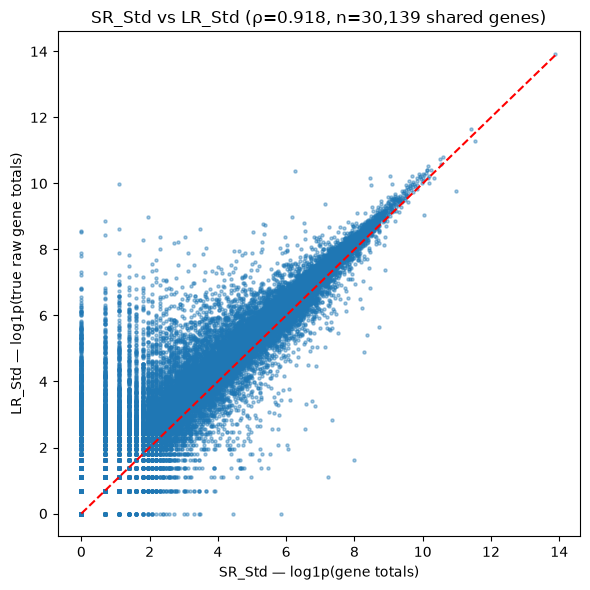

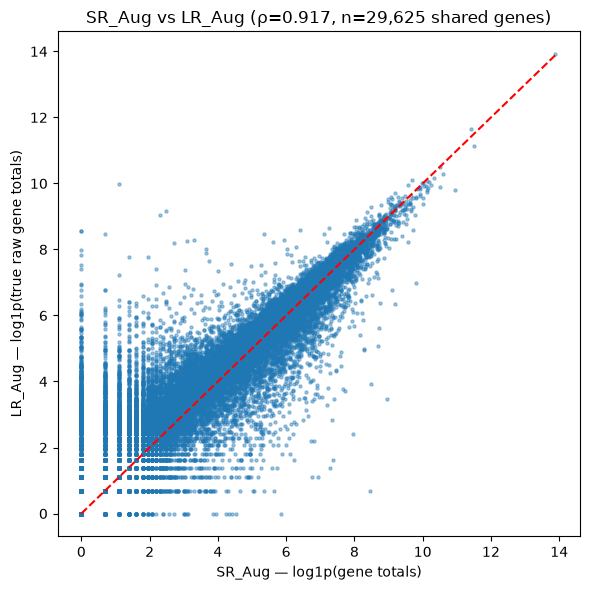

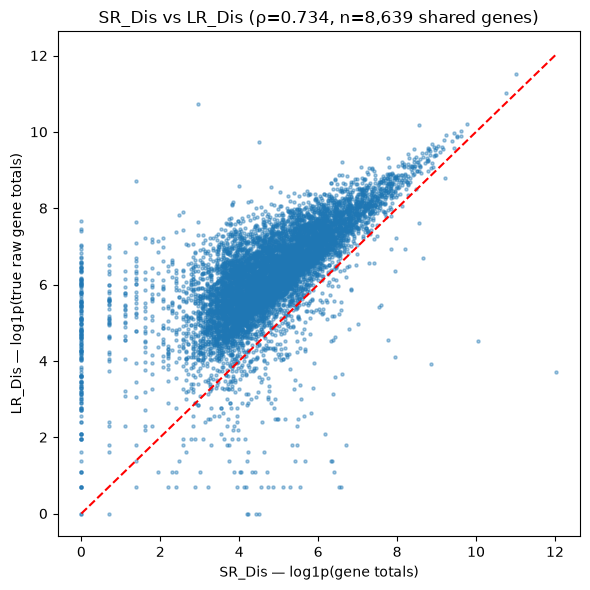

,pair,n_shared_genes,spearman_rho
0,SR_Std vs LR_Std,30139,0.917731
1,SR_Aug vs LR_Aug,29625,0.917153
2,SR_Dis vs LR_Dis,8639,0.734143


In [5]:
qc_pass_barcodes = adatas_raw['SR_Std'].obs_names.tolist()

PATH_LR_STD_RAW = "/mnt/md0/jack-gaa/wf-single-cell/SRR21492157-wf-single-cell-v2/output/SRR21492157-data/SRR21492157-data.gene_raw_feature_bc_matrix/"
PATH_LR_AUG_RAW = "/mnt/md1/jack-gaa2/wf-single-cell-gaa-augmented-31Jul2026/output/SRR21492157-data/SRR21492157-data.gene_raw_feature_bc_matrix/"
PATH_LR_DIS_RAW = "/mnt/md1/jack-gaa2/wf-single-cell-gaa-discovery-30Jul2026/output/SRR21492157-data/SRR21492157-data.gene_raw_feature_bc_matrix/"

adata_lr_std_true_raw = sc.read_10x_mtx(PATH_LR_STD_RAW, var_names='gene_symbols', cache=True)[qc_pass_barcodes].copy()

adata_lr_aug_true_raw = sc.read_10x_mtx(PATH_LR_AUG_RAW, var_names='gene_symbols', cache=True)
adata_lr_aug_true_raw.var_names = adata_lr_aug_true_raw.var_names.str.replace('.tsv', '', regex=False)
adata_lr_aug_true_raw = adata_lr_aug_true_raw[qc_pass_barcodes].copy()

adata_lr_dis_true_raw_peaks = sc.read_10x_mtx(PATH_LR_DIS_RAW, var_names='gene_symbols', cache=True)
adata_lr_dis_true_raw_peaks.var_names = adata_lr_dis_true_raw_peaks.var_names.str.replace('.tsv', '', regex=False)
adata_lr_dis_true_raw_peaks = adata_lr_dis_true_raw_peaks[qc_pass_barcodes].copy()
gmap_lr_dis_true = build_gene_map(adata_lr_dis_true_raw_peaks)
adata_lr_dis_true_raw = collapse_discovery_to_gene_level(adata_lr_dis_true_raw_peaks, gmap_lr_dis_true)

lr_true_raw = {'LR_Std': adata_lr_std_true_raw, 'LR_Aug': adata_lr_aug_true_raw, 'LR_Dis': adata_lr_dis_true_raw}

MATCHED_PAIRS = [('SR_Std', 'LR_Std'), ('SR_Aug', 'LR_Aug'), ('SR_Dis', 'LR_Dis')]

pair_results = []
for sr_name, lr_name in MATCHED_PAIRS:
    sr = adatas_genelevel[sr_name]
    lr = lr_true_raw[lr_name]
    shared_genes = sorted(set(sr.var_names) & set(lr.var_names))
    sr_totals = np.asarray(sr[:, shared_genes].X.sum(axis=0)).ravel()
    lr_totals = np.asarray(lr[:, shared_genes].X.sum(axis=0)).ravel()
    rho, _ = spearmanr(sr_totals, lr_totals)
    pair_results.append({'pair': f'{sr_name} vs {lr_name}', 'n_shared_genes': len(shared_genes), 'spearman_rho': rho})

    plt.figure(figsize=(6, 6))
    plt.scatter(np.log1p(sr_totals), np.log1p(lr_totals), s=5, alpha=0.4)
    lims = [0, max(np.log1p(sr_totals).max(), np.log1p(lr_totals).max())]
    plt.plot(lims, lims, 'r--')
    plt.xlabel(f'{sr_name} — log1p(gene totals)')
    plt.ylabel(f'{lr_name} — log1p(true raw gene totals)')
    plt.title(f'{sr_name} vs {lr_name} (ρ={rho:.3f}, n={len(shared_genes):,} shared genes)')
    plt.tight_layout()
    plt.show()

pair_summary = pd.DataFrame(pair_results)
display(pair_summary)

## Matched pairs: combined UMAP per pair

/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


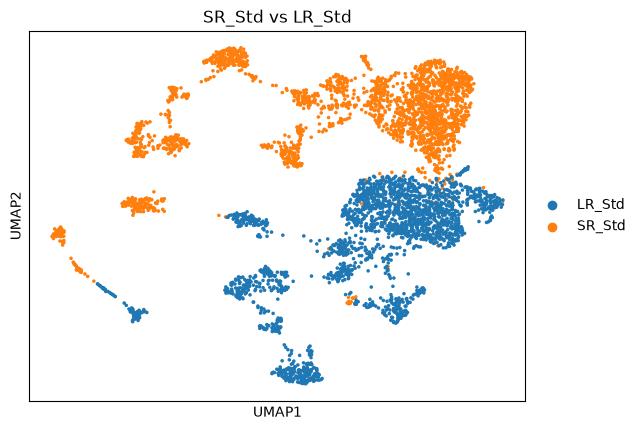

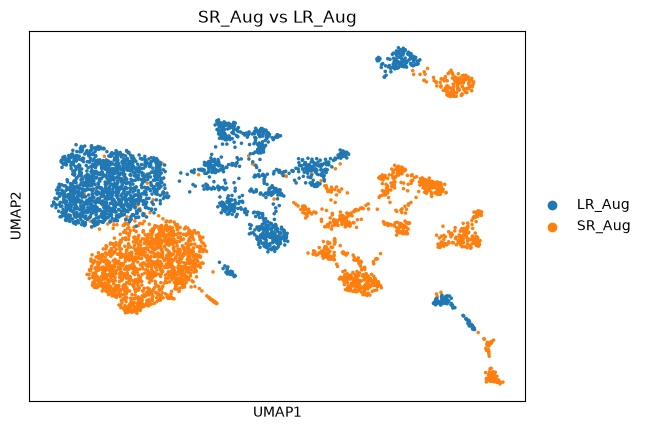

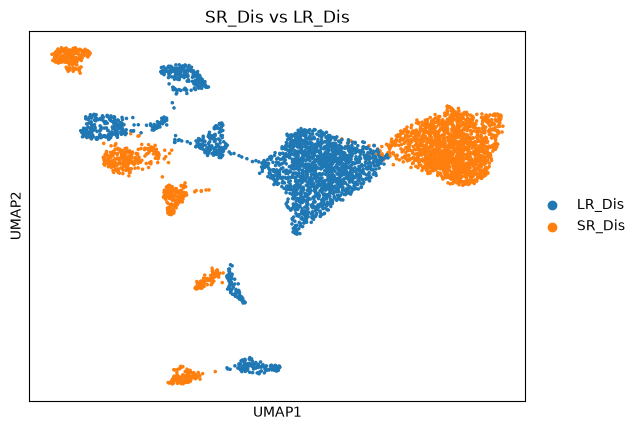

In [6]:
for sr_name, lr_name in MATCHED_PAIRS:
    pair_adatas = {sr_name: adatas_prepped[sr_name], lr_name: adatas_prepped[lr_name]}
    for name, a in pair_adatas.items():
        a.obs['dataset'] = name
    combined_pair = ad.concat(
        list(pair_adatas.values()), keys=list(pair_adatas.keys()),
        join='outer', fill_value=0, index_unique='_', label='concat_key',
    )
    sc.pp.highly_variable_genes(combined_pair, n_top_genes=3000, flavor='seurat', batch_key='dataset')
    sc.tl.pca(combined_pair, svd_solver='arpack', random_state=42)
    sc.pp.neighbors(combined_pair, n_neighbors=15, n_pcs=30, random_state=42)
    sc.tl.umap(combined_pair, random_state=42)
    sc.pl.umap(combined_pair, color='dataset', title=f'{sr_name} vs {lr_name}')

## Independent clustering all 6 conditions


In [7]:
def run_clustering(adata, name, modality):
    a = adata.copy()
    a.layers['counts'] = a.X.copy()
    if modality == 'SR':
        sc.pp.normalize_total(a, target_sum=1e4)
        sc.pp.log1p(a)
    sc.pp.highly_variable_genes(a, n_top_genes=3000, flavor='seurat')
    sc.tl.pca(a, svd_solver='arpack', random_state=42)
    sc.pp.neighbors(a, n_neighbors=15, n_pcs=30, random_state=42)
    sc.tl.umap(a, random_state=42)
    sc.tl.leiden(a, resolution=0.5, key_added='leiden', random_state=42)
    print(f"{name}: {a.obs['leiden'].nunique()} clusters")
    return a

clustered = {}
for name in ALL_CONDITIONS:
    clustered[name] = run_clustering(adatas_raw[name], name, MODALITY_OF[name])

/tmp/ipykernel_252455/1196320132.py:11: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(a, resolution=0.5, key_added='leiden', random_state=42)


SR_Std: 13 clusters


/tmp/ipykernel_252455/1196320132.py:11: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(a, resolution=0.5, key_added='leiden', random_state=42)


SR_Aug: 12 clusters


/tmp/ipykernel_252455/1196320132.py:11: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(a, resolution=0.5, key_added='leiden', random_state=42)


...

/tmp/ipykernel_252455/1196320132.py:11: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(a, resolution=0.5, key_added='leiden', random_state=42)


LR_Std: 11 clusters


/tmp/ipykernel_252455/1196320132.py:11: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(a, resolution=0.5, key_added='leiden', random_state=42)


LR_Aug: 11 clusters
LR_Dis: 10 clusters


/tmp/ipykernel_252455/1196320132.py:11: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(a, resolution=0.5, key_added='leiden', random_state=42)


## Cross-modality label transfer


=== Master reference: SR_Std ===


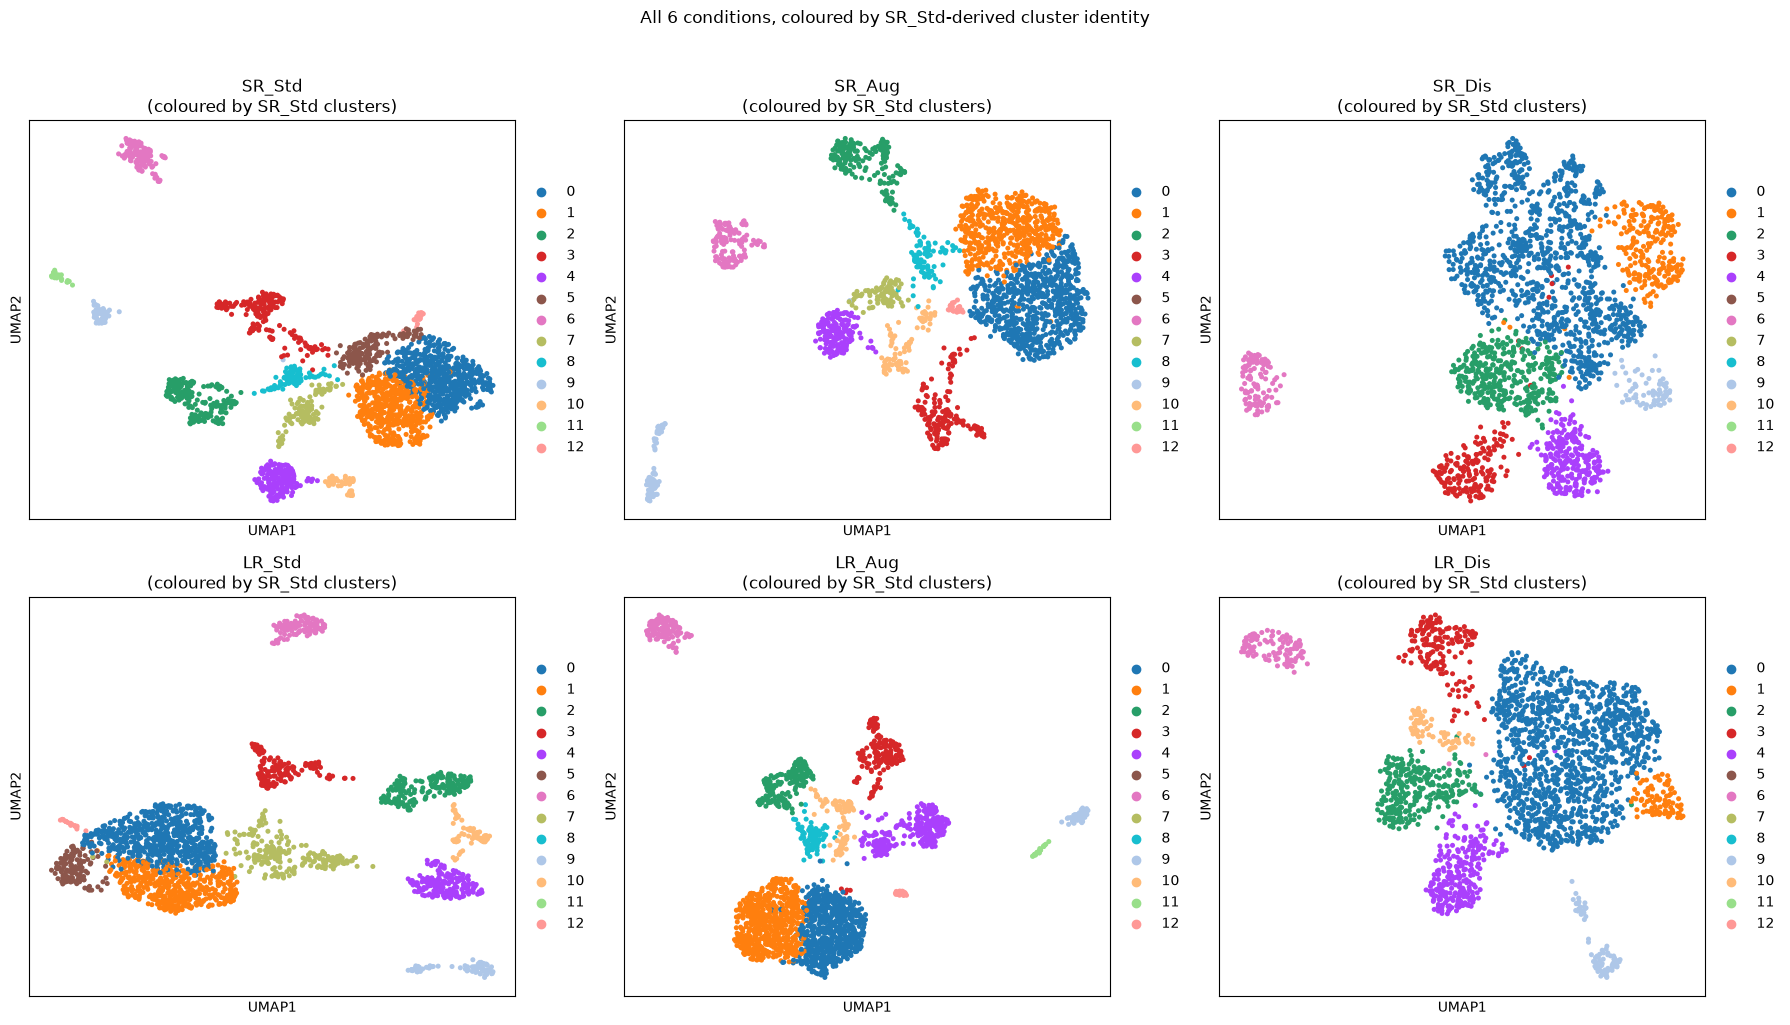


=== Master reference: LR_Std ===


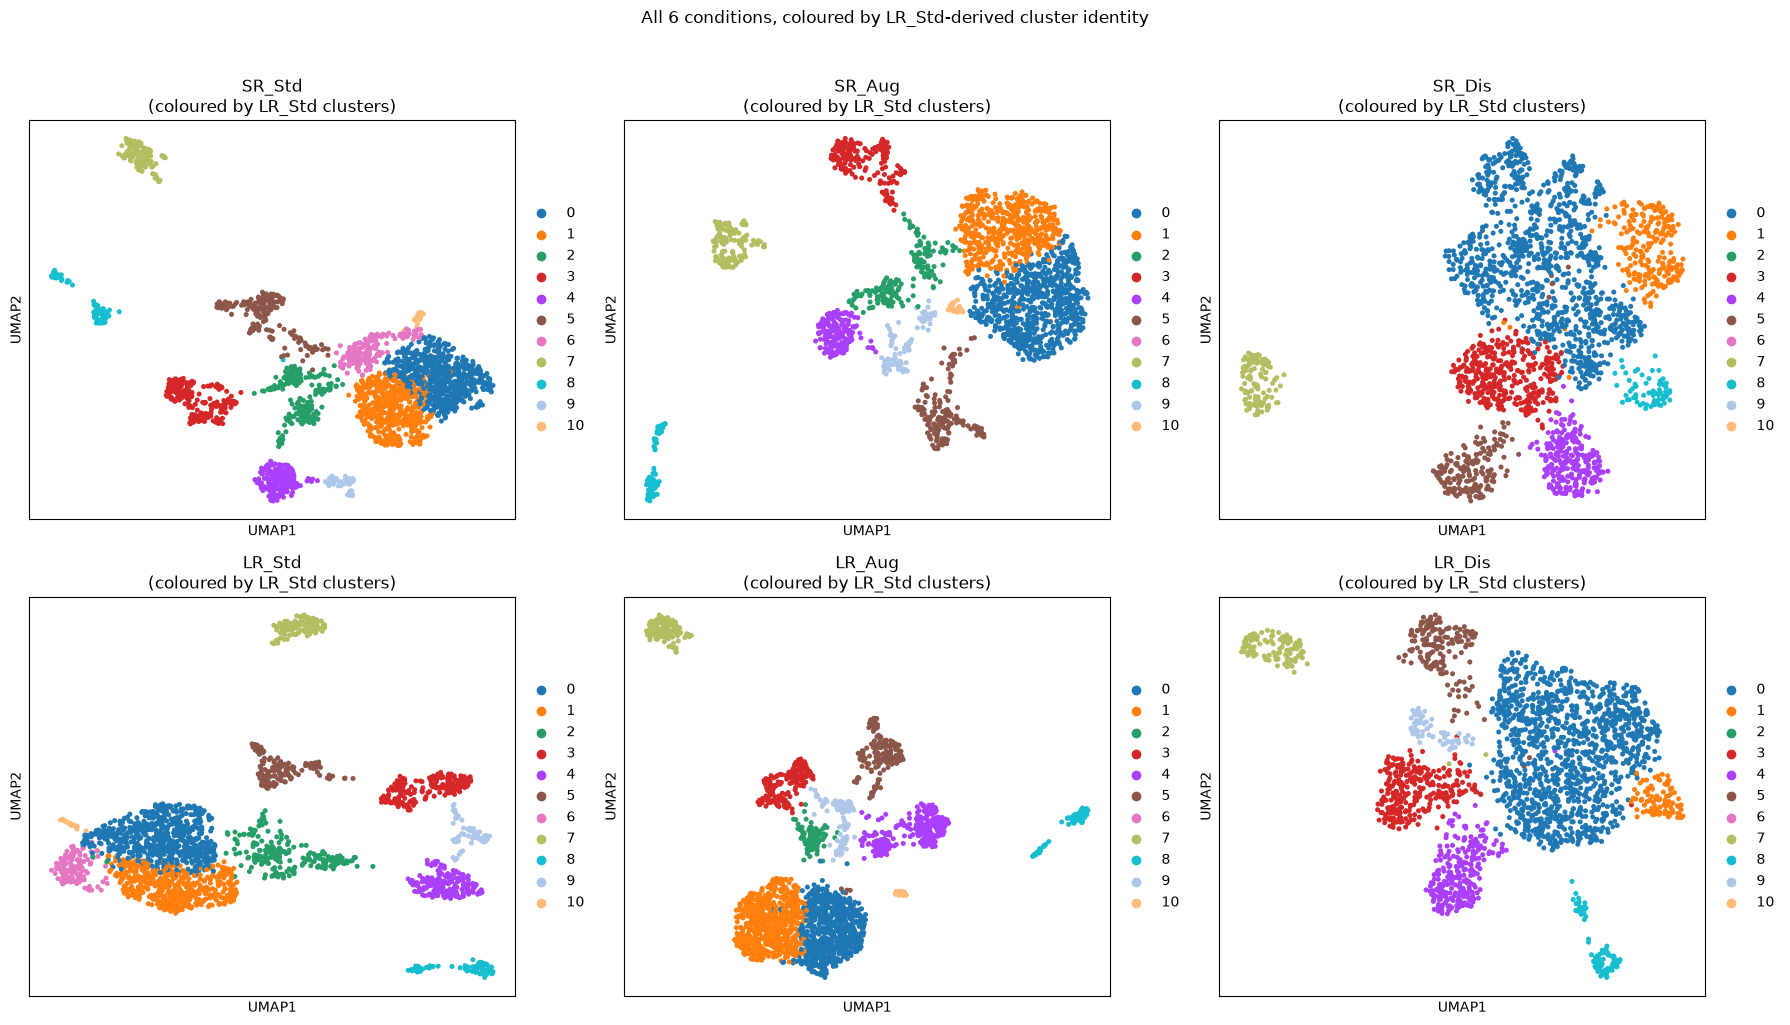


=== Master reference: LR_Aug ===


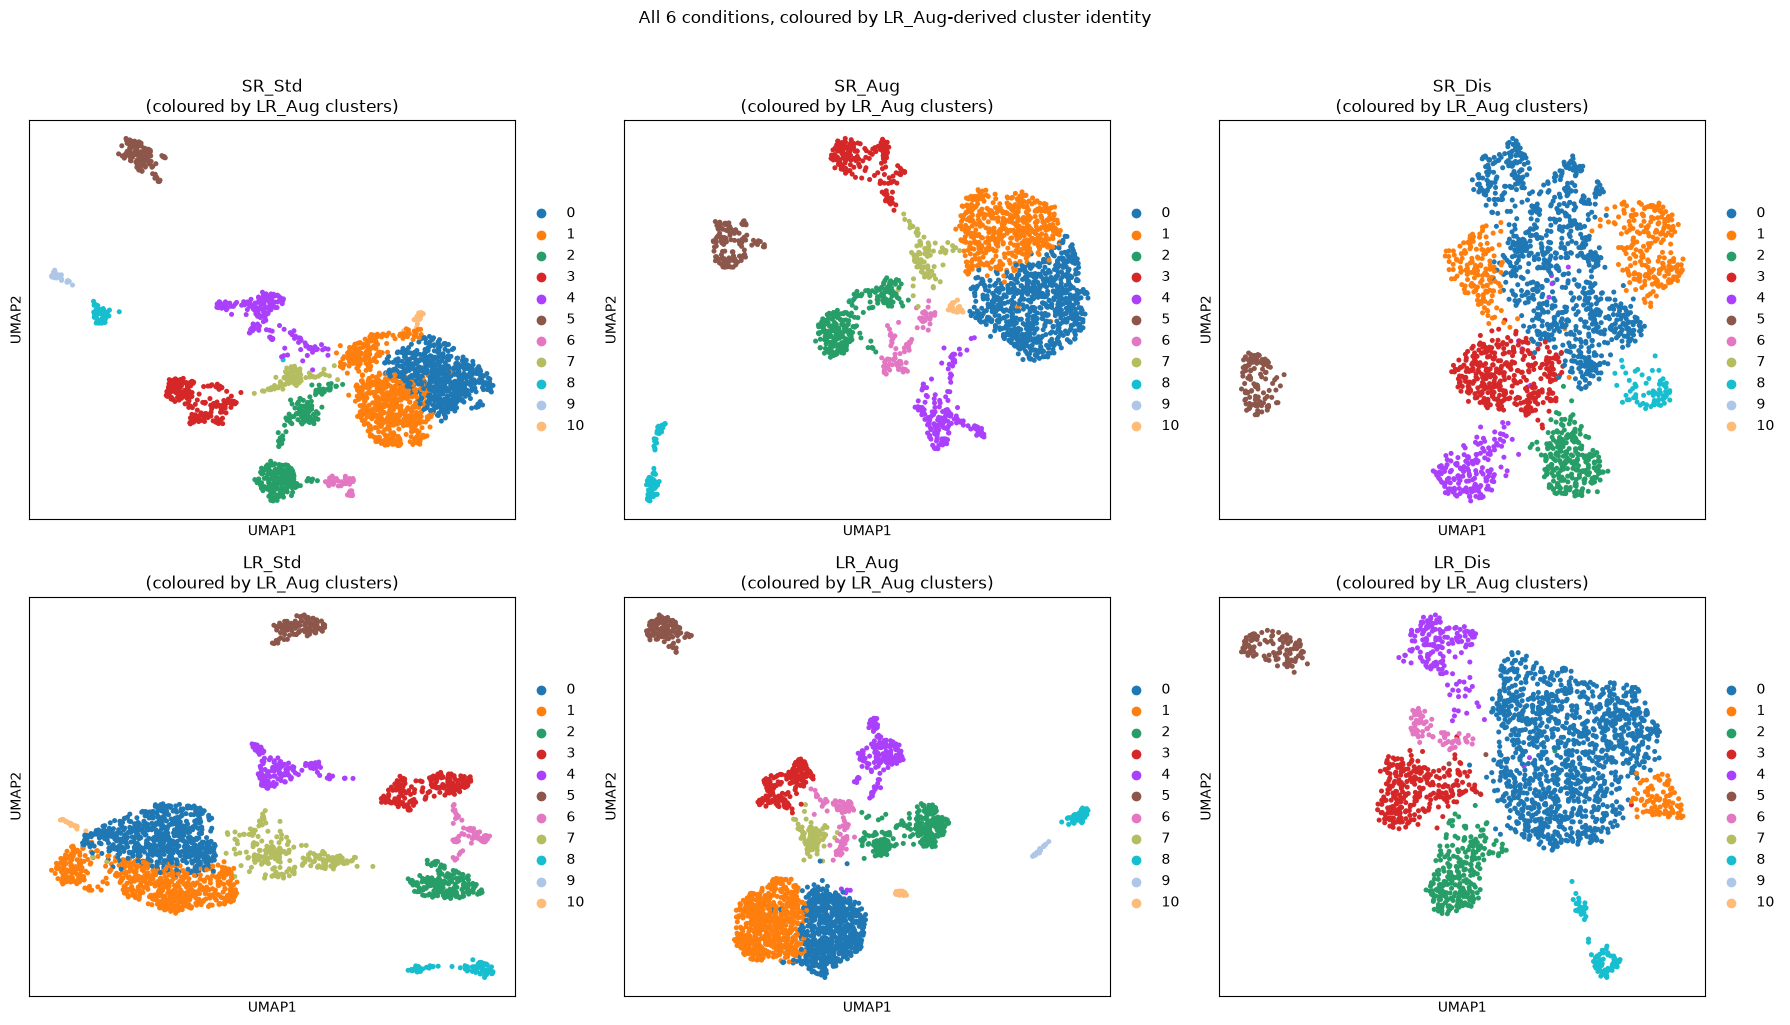

In [8]:
def transfer_labels_to_master(master_labels, other_labels):
    ct = pd.crosstab(other_labels, master_labels)
    return ct.idxmax(axis=1).to_dict()


def build_master_labelled_umaps(master_name, clustered_adatas, conditions=ALL_CONDITIONS):
    master_labels = clustered_adatas[master_name].obs['leiden'].astype(str)
    shared_categories = sorted(master_labels.unique(), key=int)

    for name in conditions:
        if name == master_name:
            labels = master_labels
        else:
            other_labels = clustered_adatas[name].obs['leiden']
            mapping = transfer_labels_to_master(master_labels, other_labels)
            labels = other_labels.map(mapping).astype(str)
        clustered_adatas[name].obs[f'mapped_to_{master_name}'] = pd.Categorical(labels, categories=shared_categories)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for ax, name in zip(axes.flat, conditions):
        sc.pl.umap(clustered_adatas[name], color=f'mapped_to_{master_name}', ax=ax, show=False,
                   title=f'{name}\n(coloured by {master_name} clusters)')
    plt.suptitle(f'All 6 conditions, coloured by {master_name}-derived cluster identity', y=1.02)
    plt.tight_layout()
    plt.show()


for master in ['SR_Std', 'LR_Std', 'LR_Aug']:
    print(f"\n=== Master reference: {master} ===")
    build_master_labelled_umaps(master, clustered)

/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
📂 Storing models in /home/jack/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)


LR_Std: loaded true raw, 2,280 cells x 30,139 features
LR_Aug: loaded true raw, 2,280 cells x 89,454 features
LR_Dis: loaded true raw, 2,280 cells x 173,032 features


🔬 Input data has 2280 cells and 38606 genes
🔗 Matching reference genes in the model
🧬 5824 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 2280 cells and 121190 genes
🔗 Matching reference genes in the model


SR_Std: 11 cell types assigned


🧬 5824 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 2280 cells and 91554 genes
🔗 Matching reference genes in the model


...

,leiden,n_distinct_celltypes,n_cells
2,2,8,233
9,9,6,67
4,4,5,180
5,5,4,148
3,3,3,184
10,10,2,22
1,1,2,484
0,0,1,639
6,6,1,134
8,8,1,79



LR_Aug: cell-type diversity per cluster


,leiden,n_distinct_celltypes,n_cells
2,2,7,264
7,7,5,89
4,4,5,176
3,3,4,182
0,0,2,660
1,1,2,603
5,5,2,115
6,6,2,91
8,8,1,53
9,9,1,27



LR_Dis: cell-type diversity per cluster


,leiden,n_distinct_celltypes,n_cells
0,0,6,504
3,3,6,277
5,5,6,174
4,4,4,261
1,1,3,370
2,2,3,351
7,7,3,91
6,6,2,109
9,9,2,67
8,8,1,76


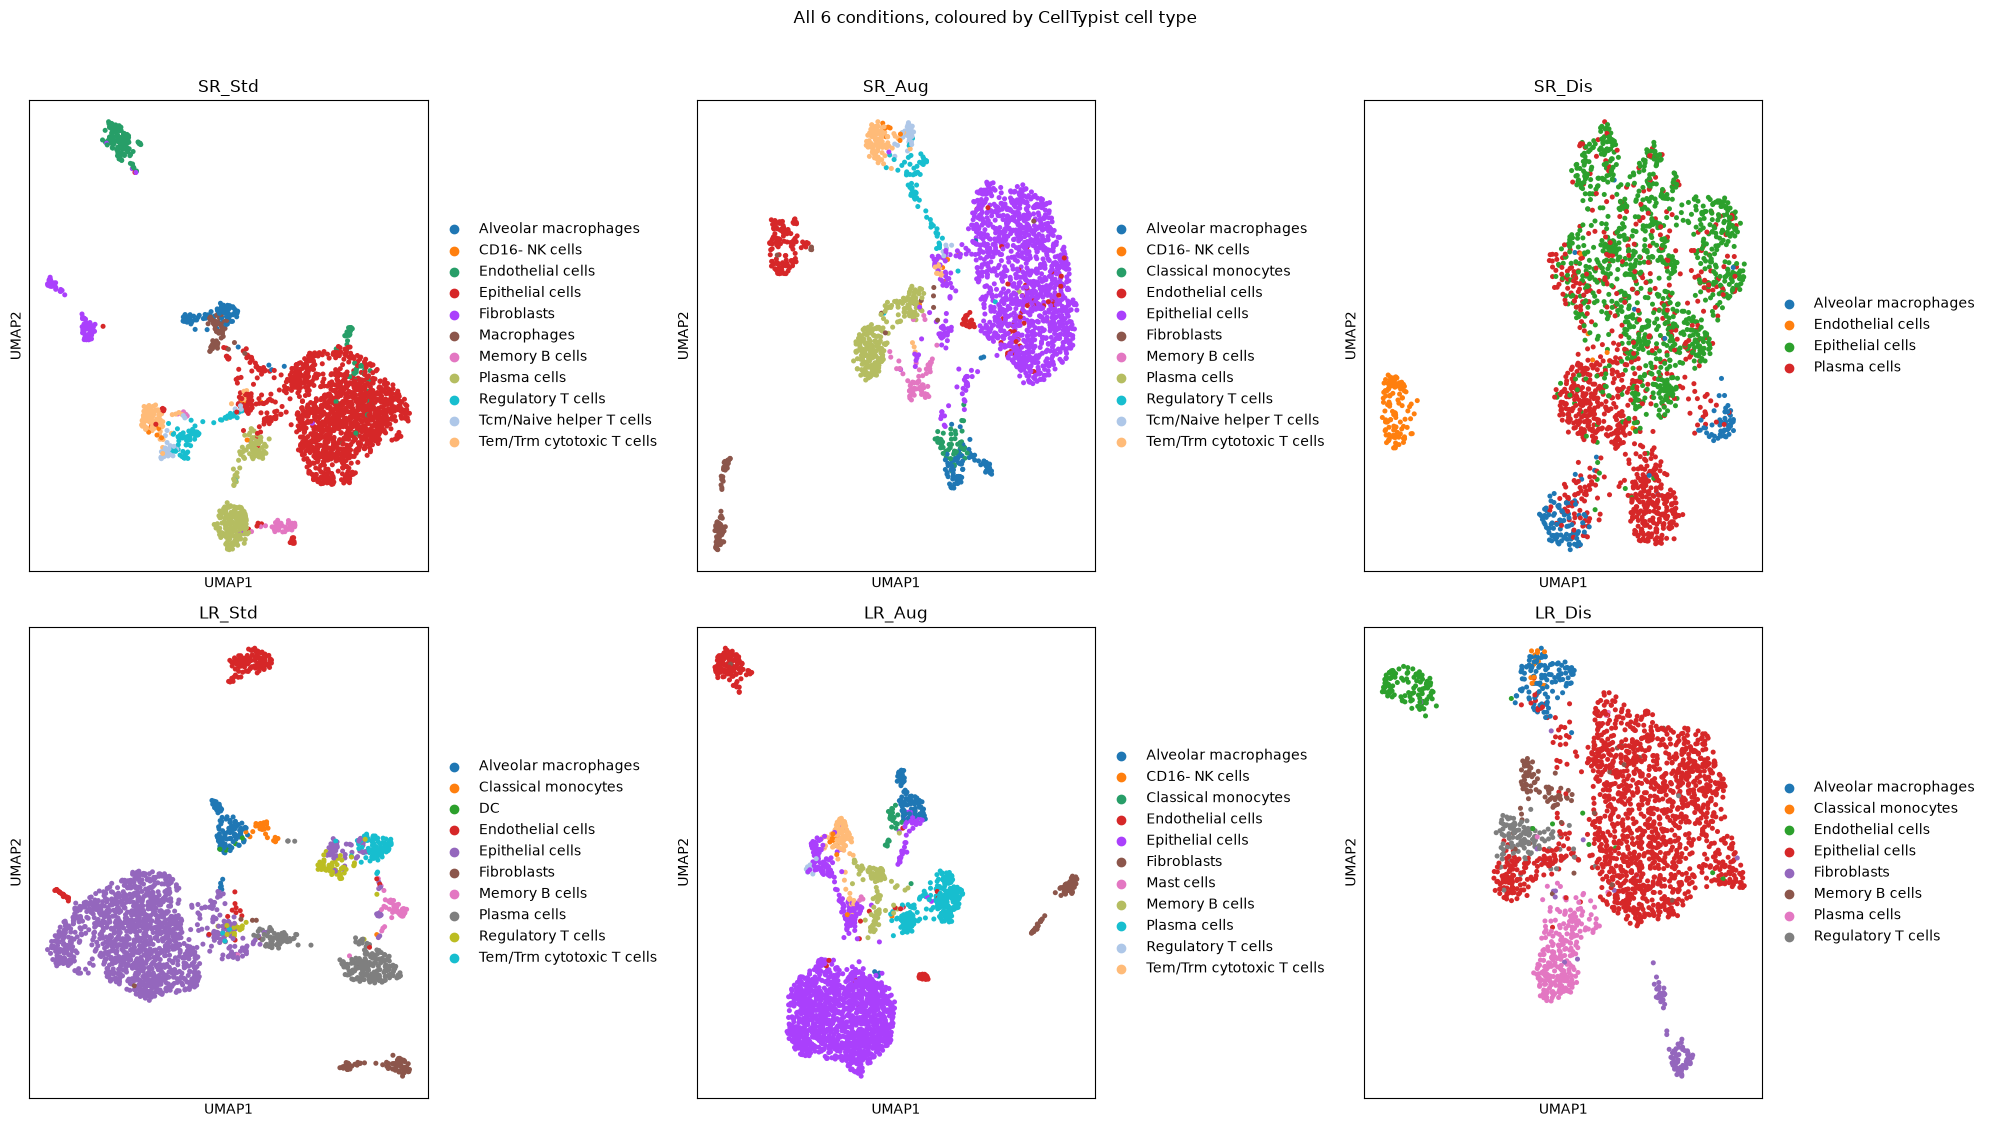


=== Cell type composition of SAT1-expressing cells ===
SR_Std: n=1116, mostly 'Epithelial cells' (54.2%)
SR_Aug: n=1116, mostly 'Epithelial cells' (52.9%)
SR_Dis: n=887, mostly 'Plasma cells' (41.7%)
LR_Std: n=1312, mostly 'Epithelial cells' (58.7%)
LR_Aug: n=1303, mostly 'Epithelial cells' (58.9%)
LR_Dis: n=1316, mostly 'Epithelial cells' (60.2%)

=== Cell type composition of FLT1-expressing cells ===
SR_Std: n=228, mostly 'Endothelial cells' (50.9%)
SR_Aug: n=227, mostly 'Endothelial cells' (51.1%)
SR_Dis: n=158, mostly 'Endothelial cells' (70.3%)
LR_Std: n=402, mostly 'Epithelial cells' (46.3%)
LR_Aug: n=352, mostly 'Epithelial cells' (45.2%)
LR_Dis: n=401, mostly 'Epithelial cells' (47.1%)

=== Cell type composition of VEGFA-expressing cells ===
SR_Std: n=1558, mostly 'Epithelial cells' (83.6%)
SR_Aug: n=1558, mostly 'Epithelial cells' (81.1%)
SR_Dis: n=1467, mostly 'Epithelial cells' (66.1%)
LR_Std: n=1600, mostly 'Epithelial cells' (83.5%)
LR_Aug: n=1600, mostly 'Epithelial cell

In [9]:
import celltypist
from celltypist import models

models.download_models(model=['Immune_All_Low.pkl'])

celltypist_adatas = {
    'SR_Std': adatas_prepped['SR_Std'].copy(),
    'SR_Aug': adatas_prepped['SR_Aug'].copy(),
    'SR_Dis': adatas_prepped['SR_Dis'].copy(),
}


PATH_LR_STD_RAW = "/mnt/md0/jack-gaa/wf-single-cell/SRR21492157-wf-single-cell-v2/output/SRR21492157-data/SRR21492157-data.gene_raw_feature_bc_matrix/"
PATH_LR_AUG_RAW = "/mnt/md1/jack-gaa2/wf-single-cell-gaa-augmented-31Jul2026/output/SRR21492157-data/SRR21492157-data.gene_raw_feature_bc_matrix/"
PATH_LR_DIS_RAW = "/mnt/md1/jack-gaa2/wf-single-cell-gaa-discovery-30Jul2026/output/SRR21492157-data/SRR21492157-data.gene_raw_feature_bc_matrix/"

qc_pass_barcodes = adatas_raw['SR_Std'].obs_names.tolist()

lr_raw_paths = {'LR_Std': PATH_LR_STD_RAW, 'LR_Aug': PATH_LR_AUG_RAW, 'LR_Dis': PATH_LR_DIS_RAW}
lr_true_raw = {}
for name, path in lr_raw_paths.items():
    a = sc.read_10x_mtx(path, var_names='gene_symbols', cache=True)
    if name != 'LR_Std':
        a.var_names = a.var_names.str.replace('.tsv', '', regex=False)
    lr_true_raw[name] = a[qc_pass_barcodes].copy()
    print(f"{name}: loaded true raw, {lr_true_raw[name].n_obs:,} cells x {lr_true_raw[name].n_vars:,} features")


gmap_lr_dis_true = build_gene_map(lr_true_raw['LR_Dis'])
lr_dis_true_collapsed = collapse_discovery_to_gene_level(lr_true_raw['LR_Dis'], gmap_lr_dis_true)

for name in ['LR_Std', 'LR_Aug']:
    a = lr_true_raw[name].copy()
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)
    celltypist_adatas[name] = a

a = lr_dis_true_collapsed.copy()
sc.pp.normalize_total(a, target_sum=1e4)
sc.pp.log1p(a)
celltypist_adatas['LR_Dis'] = a



for name, adata in celltypist_adatas.items():
    predictions = celltypist.annotate(adata, model='Immune_All_Low.pkl', majority_voting=True)
    label_series = predictions.predicted_labels['majority_voting']
    label_series.index = adata.obs_names
    clustered[name].obs['celltypist_label'] = label_series.reindex(clustered[name].obs_names).values
    print(f"{name}: {clustered[name].obs['celltypist_label'].nunique()} cell types assigned")




def cell_type_diversity_per_cluster(adata, name):
    diversity = adata.obs.groupby('leiden')['celltypist_label'].nunique().reset_index(name='n_distinct_celltypes')
    diversity['n_cells'] = adata.obs.groupby('leiden').size().values
    diversity = diversity.sort_values('n_distinct_celltypes', ascending=False)
    print(f"\n{name}: cell-type diversity per cluster")
    display(diversity)
    return diversity

diversity_results = {name: cell_type_diversity_per_cluster(clustered[name], name) for name in ALL_CONDITIONS}



fig, axes = plt.subplots(2, 3, figsize=(20, 11))
for ax, name in zip(axes.flat, ALL_CONDITIONS):
    sc.pl.umap(clustered[name], color='celltypist_label', ax=ax, show=False, title=name)
plt.suptitle('All 6 conditions, coloured by CellTypist cell type', y=1.02)
plt.tight_layout()
plt.show()


HEADLINE_GENES_SIMPLE = ['SAT1', 'FLT1', 'VEGFA']

def get_expression_for_gene(adata, gene_name):
    """For Std/Aug (clean gene symbols) matches directly. For Dis (pipe-format peak
    IDs), matches by parsed gene context and sums across every matching peak — same
    approach already validated in scripts 1/2's gene_case_study."""
    if gene_name in adata.var_names:
        return np.asarray(adata[:, gene_name].X.todense()).ravel()
    matches = [v for v in adata.var_names
               if '|' in v and v.split('|')[0] == gene_name]
    if not matches:
        return None
    return np.asarray(adata[:, matches].X.sum(axis=1)).ravel()


for gene in HEADLINE_GENES_SIMPLE:
    print(f"\n=== Cell type composition of {gene}-expressing cells ===")
    for name in ALL_CONDITIONS:
        adata = clustered[name]
        expr = get_expression_for_gene(adata, gene)
        if expr is None:
            print(f"{name}: {gene} not present")
            continue
        expressing = adata.obs[expr > 0]
        if len(expressing) == 0:
            print(f"{name}: no expressing cells")
            continue
        top_type = expressing['celltypist_label'].value_counts().idxmax()
        pct = 100 * expressing['celltypist_label'].value_counts().max() / len(expressing)
        print(f"{name}: n={len(expressing)}, mostly '{top_type}' ({pct:.1f}%)")

In [10]:
def alluvial_sr_vs_lr(sr_name, lr_name):
    sr_labels = clustered[sr_name].obs['celltypist_label'].astype(str)
    lr_labels = clustered[lr_name].obs['celltypist_label'].astype(str).reindex(sr_labels.index)

    pct_consistent = 100 * (sr_labels == lr_labels).mean()
    print(f"{sr_name} vs {lr_name}: {pct_consistent:.1f}% of cells get the SAME CellTypist call in both modalities")

    ct = pd.crosstab(sr_labels, lr_labels)
    display(ct)
    return pct_consistent


consistency_results = {}
for sr_name, lr_name in MATCHED_PAIRS:
    consistency_results[(sr_name, lr_name)] = alluvial_sr_vs_lr(sr_name, lr_name)

SR_Std vs LR_Std: 90.9% of cells get the SAME CellTypist call in both modalities


celltypist_label,Alveolar macrophages,Classical monocytes,DC,Endothelial cells,Epithelial cells,Fibroblasts,Memory B cells,Plasma cells,Regulatory T cells,Tem/Trm cytotoxic T cells
celltypist_label,,,,,,,,,,
Alveolar macrophages,82,0,8,0,4,0,0,0,0,0
CD16- NK cells,0,0,0,0,12,0,0,0,0,0
Endothelial cells,0,0,0,135,27,0,0,0,0,0
Epithelial cells,2,9,0,6,1343,1,1,5,2,10
Fibroblasts,0,0,0,1,0,84,0,0,0,0
Macrophages,29,20,1,1,0,0,0,0,0,0
Memory B cells,0,0,0,0,0,0,48,0,0,0
Plasma cells,0,0,0,0,1,0,0,241,0,0
Regulatory T cells,0,0,0,0,8,0,0,0,63,1


SR_Aug vs LR_Aug: 88.2% of cells get the SAME CellTypist call in both modalities


celltypist_label,Alveolar macrophages,CD16- NK cells,Classical monocytes,Endothelial cells,Epithelial cells,Fibroblasts,Mast cells,Memory B cells,Plasma cells,Regulatory T cells,Tem/Trm cytotoxic T cells
celltypist_label,,,,,,,,,,,
Alveolar macrophages,85,0,0,0,10,0,0,0,0,0,0
CD16- NK cells,0,12,0,0,0,0,0,0,0,0,0
Classical monocytes,23,0,20,0,10,0,0,0,0,0,0
Endothelial cells,0,0,0,135,44,0,0,0,0,0,0
Epithelial cells,0,0,8,3,1273,0,3,34,2,0,4
Fibroblasts,0,0,0,9,0,81,1,0,1,0,0
Memory B cells,0,0,0,0,0,0,0,63,2,0,0
Plasma cells,0,0,0,0,2,0,0,0,241,0,0
Regulatory T cells,0,0,0,0,63,0,0,0,0,11,0


SR_Dis vs LR_Dis: 65.6% of cells get the SAME CellTypist call in both modalities


celltypist_label,Alveolar macrophages,Classical monocytes,Endothelial cells,Epithelial cells,Fibroblasts,Memory B cells,Plasma cells,Regulatory T cells
celltypist_label,,,,,,,,
Alveolar macrophages,86,8,0,7,53,0,0,0
Endothelial cells,0,0,113,0,1,0,0,0
Epithelial cells,1,0,0,1043,1,5,5,12
Plasma cells,36,6,1,433,34,81,253,101


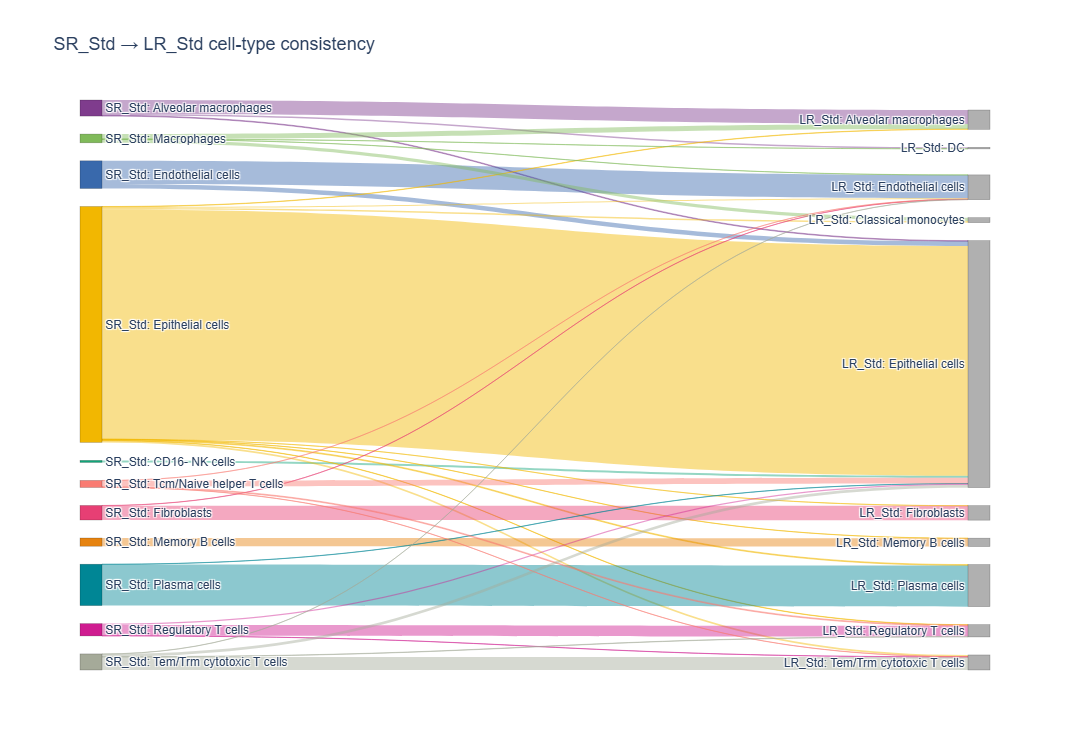

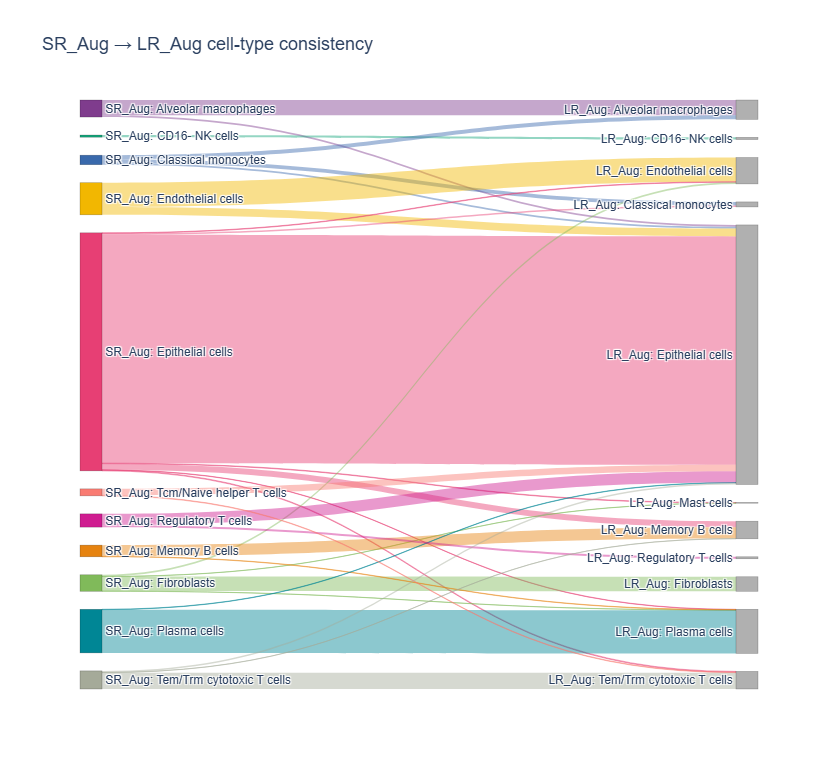

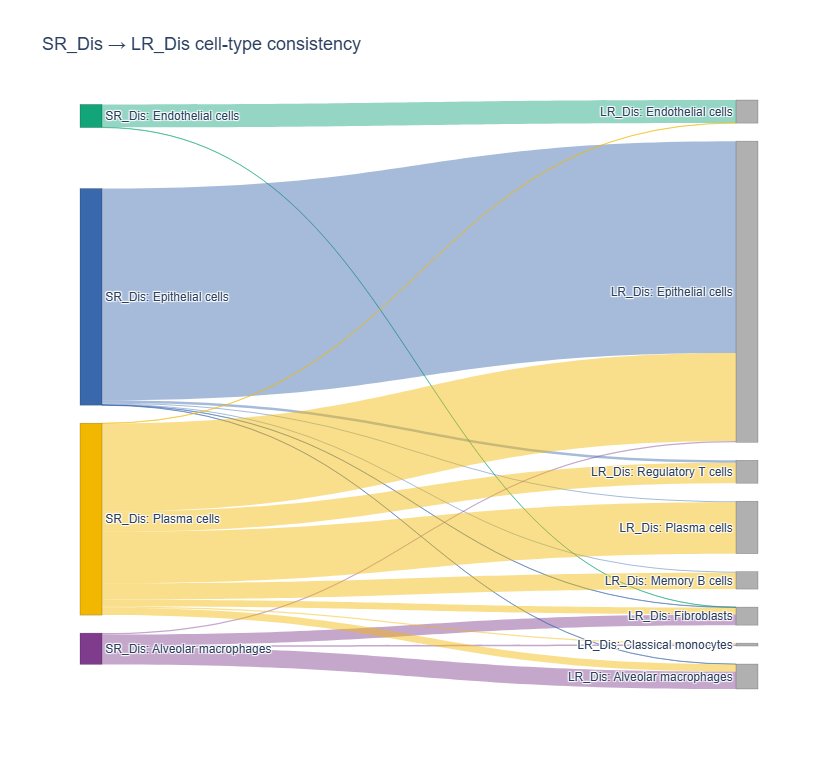

In [11]:

def build_celltype_sankey(sr_labels, lr_labels, sr_name, lr_name, title):
    df = pd.DataFrame({'SR': sr_labels.values, 'LR': lr_labels.values})
    flow = df.groupby(['SR', 'LR']).size().reset_index(name='count')

    sr_types = sorted(df['SR'].unique())
    lr_types = sorted(df['LR'].unique())

    sr_node_labels = [f"{sr_name}: {t}" for t in sr_types]
    lr_node_labels = [f"{lr_name}: {t}" for t in lr_types]
    all_labels = sr_node_labels + lr_node_labels

    sr_idx = {t: i for i, t in enumerate(sr_types)}
    lr_idx = {t: i + len(sr_types) for i, t in enumerate(lr_types)}

    palette = px.colors.qualitative.Bold + px.colors.qualitative.Set3 + px.colors.qualitative.Pastel
    node_colors = [palette[i % len(palette)] for i in range(len(sr_types))] + ['#B0B0B0'] * len(lr_types)

    def hex_to_rgba(hex_color, alpha=0.45):
        h = hex_color.lstrip('#')
        if len(h) == 6:
            r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        else:
            nums = hex_color.strip('rgb()').split(',')
            r, g, b = [int(float(n)) for n in nums[:3]]
        return f'rgba({r},{g},{b},{alpha})'

    sources, targets, values, link_colors = [], [], [], []
    for _, row in flow.iterrows():
        src = sr_idx[row['SR']]
        sources.append(src)
        targets.append(lr_idx[row['LR']])
        values.append(row['count'])
        link_colors.append(hex_to_rgba(node_colors[src]))

    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(pad=18, thickness=22, line=dict(color="rgba(0,0,0,0.3)", width=0.6),
                  label=all_labels, color=node_colors),
        link=dict(source=sources, target=targets, value=values, color=link_colors),
    )])
    fig.update_layout(title=dict(text=title, font=dict(size=18)), font=dict(size=12, family="Arial"),
                       height=750, width=950, paper_bgcolor='white', plot_bgcolor='white')
    return fig


out_dir = '/mnt/md0/jack-gaa/gaa/analysis/sankeys'
os.makedirs(out_dir, exist_ok=True)

for sr_name, lr_name in MATCHED_PAIRS:
    sr_labels = clustered[sr_name].obs['celltypist_label'].astype(str)
    lr_labels = clustered[lr_name].obs['celltypist_label'].astype(str).reindex(sr_labels.index)

    fig = build_celltype_sankey(sr_labels, lr_labels, sr_name, lr_name,
                                 f'{sr_name} → {lr_name} cell-type consistency')
    fig.write_html(f'{out_dir}/{sr_name.lower()}_vs_{lr_name.lower()}_celltype_sankey.html')
    fig.show()